<a href="https://colab.research.google.com/github/amanranjotprince/Training-TR-103-report/blob/main/Day25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#K-Means

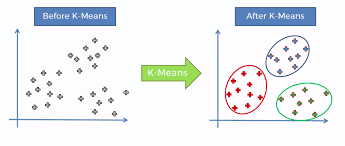



<img src="https://stanford.edu/~cpiech/cs221/img/kmeansViz.png" width=600px>



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhruvalpatel30/driver-dataset")

print("Path to dataset files:", path)

100%|██████████| 25.1k/25.1k [00:00<00:00, 13.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dhruvalpatel30/driver-dataset/versions/1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('driver-data.csv')
df

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
...,...,...,...
3995,3423310685,160.04,10
3996,3423312600,176.17,5
3997,3423312921,170.91,12
3998,3423313630,176.14,5


In [4]:
X = df.iloc[:, 1:]
X

,mean_dist_day,mean_over_speed_perc
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25
...,...,...
3995,160.04,10
3996,176.17,5
3997,170.91,12
3998,176.14,5


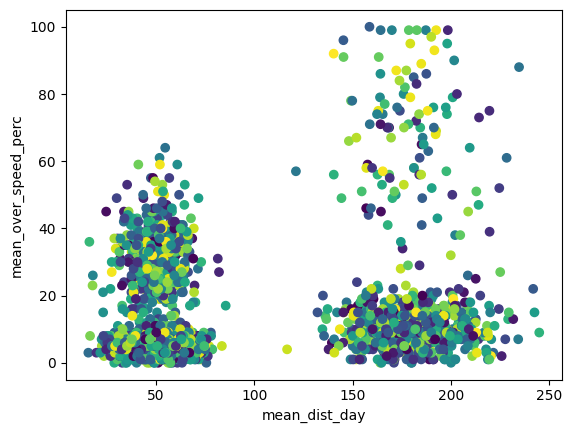

In [5]:
plt.xlabel('mean_dist_day')
plt.ylabel('mean_over_speed_perc')
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df['id'])
plt.show()

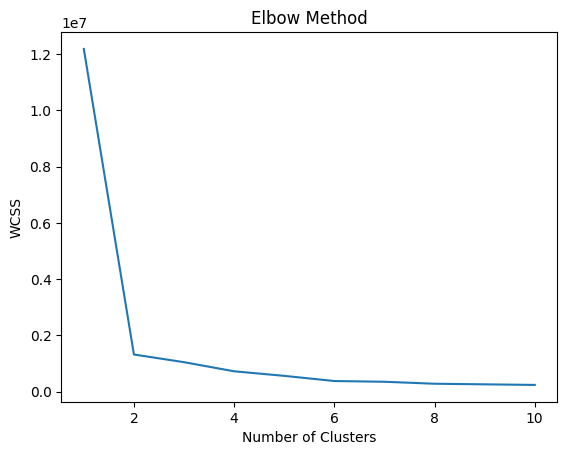

In [6]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [7]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, init='k-means++')

In [8]:
model = kmeans.fit(X)

In [9]:
model.cluster_centers_

array([[ 50.04763437,   8.82875   ],
       [180.017075  ,  18.29      ]])

In [10]:
labels = model.labels_
labels

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [11]:
df['Cluster_labels'] = labels
df

,id,mean_dist_day,mean_over_speed_perc,Cluster_labels
0,3423311935,71.24,28,0
1,3423313212,52.53,25,0
2,3423313724,64.54,27,0
3,3423311373,55.69,22,0
4,3423310999,54.58,25,0
...,...,...,...,...
3995,3423310685,160.04,10,1
3996,3423312600,176.17,5,1
3997,3423312921,170.91,12,1
3998,3423313630,176.14,5,1


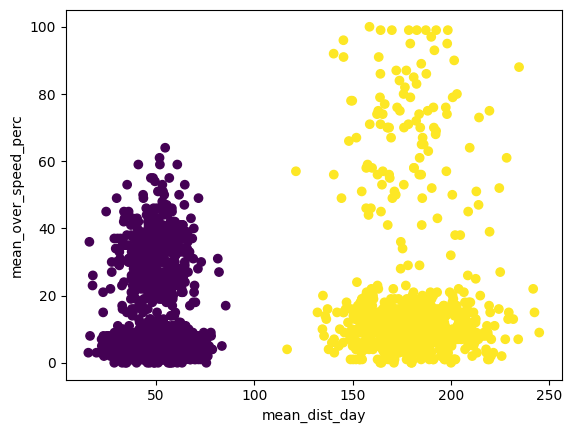

In [12]:
plt.xlabel('mean_dist_day')
plt.ylabel('mean_over_speed_perc')
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df['Cluster_labels'])
plt.show()